# Physical Data Analysis

First, let's import the needed libraries: Pandas

In [35]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

Load all the csv files and merge them into one dataframe

In [36]:
phy1 = pd.read_csv("/Users/Tatum/Downloads/Physical dataset/phy_att_1.csv", encoding="utf-16", sep="\t", engine="python")
phy2 = pd.read_csv("/Users/Tatum/Downloads/Physical dataset/phy_att_2.csv", encoding="utf-16", sep="\t", engine="python")
phy3 = pd.read_csv("/Users/Tatum/Downloads/Physical dataset/phy_att_3.csv", encoding="utf-16", sep="\t", engine="python")
phy4 = pd.read_csv("/Users/Tatum/Downloads/Physical dataset/phy_norm.csv", encoding="utf-16", sep="\t", engine="python")
phy5 = pd.read_csv("/Users/Tatum/Downloads/Physical dataset/phy_att_4.csv", encoding="utf-8-sig")
df = pd.concat([phy1, phy2, phy3, phy4], ignore_index=True)
df.head()

,Time,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8,Pump_1,...,Valv_16,Valv_17,Valv_18,Valv_19,Valv_20,Valv_21,Valv_22,Label_n,Label,Lable_n
0,09/04/2021 18:23:28,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,0.0,normal,NaN
1,09/04/2021 18:23:29,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,0.0,normal,NaN
2,09/04/2021 18:23:30,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,0.0,normal,NaN
3,09/04/2021 18:23:31,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,0.0,normal,NaN
4,09/04/2021 18:23:32,0,0,0,0,0,0,0,0,True,...,False,False,False,False,False,False,False,0.0,normal,NaN


## Basic data analysis

use .shape to find out the number of rows and columns in the data

In [37]:
df.shape

(9206, 44)

The data has 7495 rows and 44 columns

Use .info to get information about the 44 columns:

In [38]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9206 entries, 0 to 9205
Data columns (total 44 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time           9206 non-null   object 
 1   Tank_1         9206 non-null   int64  
 2   Tank_2         9206 non-null   int64  
 3   Tank_3         9206 non-null   int64  
 4   Tank_4         9206 non-null   int64  
 5   Tank_5         9206 non-null   int64  
 6   Tank_6         9206 non-null   int64  
 7   Tank_7         9206 non-null   int64  
 8   Tank_8         9206 non-null   int64  
 9   Pump_1         9206 non-null   bool   
 10  Pump_2         9206 non-null   bool   
 11  Pump_3         9206 non-null   bool   
 12  Pump_4         9206 non-null   bool   
 13  Pump_5         9206 non-null   bool   
 14  Pump_6         9206 non-null   bool   
 15  Flow_sensor_1  9206 non-null   int64  
 16  Flow_sensor_2  9206 non-null   int64  
 17  Flow_sensor_3  9206 non-null   int64  
 18  Flow_sen

The columns Label_n and Lable_n are the only columns with null values. Could be a possible naming error.

Use .describe to find basic statistics for columns

In [39]:
df.describe()

,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8,Flow_sensor_1,Flow_sensor_2,Flow_sensor_3,Flow_sensor_4,Label_n,Lable_n
count,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000,9206.0,9206.000000,7102.000000,2104.000000
mean,713.299044,927.126331,599.947100,282.917662,369.751792,196.465892,181.571367,170.329350,1504.073430,1536.823811,0.0,1370.671193,0.162349,0.145437
std,674.443296,692.773529,637.118395,351.902953,278.551885,174.515899,198.406152,183.080949,1936.933331,1945.733553,0.0,1813.197584,0.368796,0.352625
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,4.000000,104.250000,98.250000,20.000000,60.250000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,613.000000,1001.000000,412.000000,33.000000,386.000000,181.000000,104.000000,91.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,1307.750000,1580.000000,960.750000,554.000000,610.000000,375.750000,369.000000,361.000000,4000.000000,4000.000000,0.0,2975.000000,0.000000,0.000000
max,2021.000000,2012.000000,3427.000000,1143.000000,838.000000,800.000000,812.000000,507.000000,4000.000000,4000.000000,0.0,4789.000000,1.000000,1.000000


Look for duplicated rows

In [40]:
df.duplicated().sum()

np.int64(0)

Find any outliers

In [41]:
# 1) Select only numeric columns
num_cols = df.select_dtypes(include='number').columns.tolist()

# 2) Find columns with z-scores greater than 3
outliers = (np.abs(stats.zscore(df[num_cols].fillna(0))) > 3.0)
outliers_df = pd.DataFrame(outliers, columns=num_cols, index=df.index)

# 3) counts per column (which columns have outliers)
col_outlier_counts = outliers_df.sum().sort_values(ascending=False)
print(col_outlier_counts.head())


Lable_n    306
Tank_3     237
Tank_7      57
Tank_6      21
Tank_1       0
dtype: int64


Tank_3, Tank_7, and Tank_6 are the only columns with outliers, we can ignore Lable_n outliers.

# Visualizations

Make plots of the columns producing outliers

<Axes: xlabel='Time', ylabel='Tank_3'>

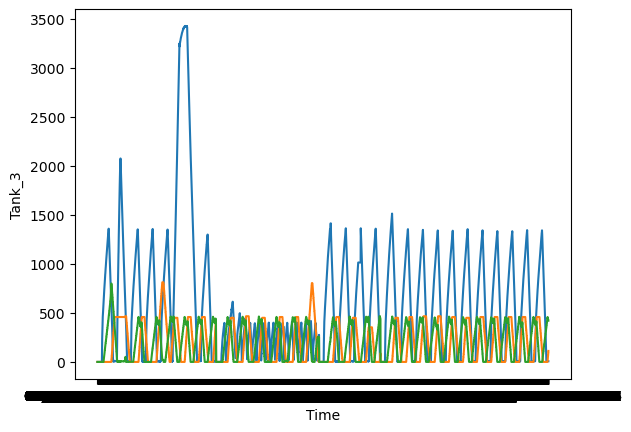

In [42]:
sns.lineplot(data=df, x='Time', y='Tank_3')
sns.lineplot(data=df, x='Time', y='Tank_7')
sns.lineplot(data=df, x='Time', y='Tank_6')

Create a heat plot of the columns correlation to each other

<Axes: >

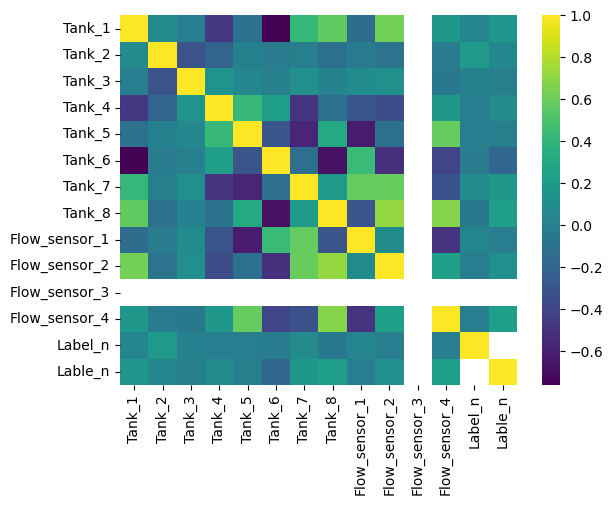

In [43]:
sns.heatmap(df[num_cols].corr(), cmap='viridis')

Investigate why flow sensor 3 has no correlations

In [76]:
df['Flow_sensor_3'].nlargest(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Flow_sensor_3, dtype: int64

Flow_sensor_3 has only zeroes

# Find out information on the label columns 

In [77]:
print(df.groupby('Label_n').size() + df.groupby('Lable_n').size())


Label_n
0.0    7747
1.0    1459
dtype: int64


There are 7747 rows labeled normal and 1459 rows labeled attack.

In [72]:
pd.pivot_table(df, index='Label_n', values=('Tank_1', 'Tank_2', 'Tank_3', 'Tank_4', 'Tank_5', 'Tank_6', 'Tank_7', 'Tank_8',))

,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8
Label_n,,,,,,,,
0.0,700.453858,676.770718,705.425954,353.94083,368.937132,203.424273,175.046058,176.996806
1.0,775.217693,1000.822203,715.986123,334.82307,353.061578,186.566349,215.457936,152.381613


<Axes: xlabel='Time', ylabel='Tank_1'>

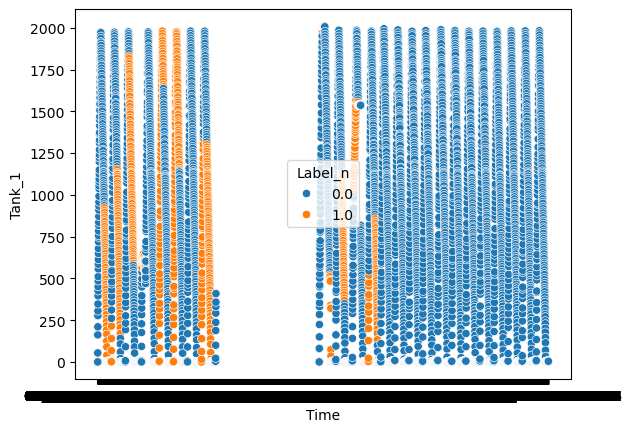

In [73]:
sns.scatterplot(data=df, x='Time', y='Tank_1', hue='Label_n')

## Mean tank values over time by label_n
Compute the mean of each Tank at each timestamp for each value of `Label_n` (handles `Lable_n` typo) and plot one subplot per tank with lines for each label value.

In [ ]:
# concise: mean per Time × label and plot per tank
label_col = next((c for c in ['Label_n','Lable_n'] if c in df.columns), None)
tank_cols = [c for c in df.columns if c.lower().startswith('tank_')]
if label_col is None or not tank_cols:
    print('Missing label or tank columns; check df.columns')
else:
    grp = df.dropna(subset=['Time']).groupby([pd.Grouper(key='Time'), label_col])[tank_cols].mean()
    # unstack label so for each tank we get columns = label values
    un = grp.unstack(level=-1)
    import matplotlib.dates as mdates
    sns.set_style('whitegrid')
    fig, axes = plt.subplots(len(tank_cols), 1, figsize=(12, 3*len(tank_cols)), sharex=True)
    if len(tank_cols) == 1:
        axes = [axes]
    for ax, tank in zip(axes, tank_cols):
        # un[tank] is a DataFrame columns=label values